In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.float_format", lambda x: "%.4f" % x)


In [2]:
import os
import pandas as pd

DATASET_PATH = "/Users/macbookair/Desktop/IDS_DASHBOARD/CIC-IDS2017"

def load_cicids(path):
    dfs = []
    for file in os.listdir(path):
        if file.endswith(".parquet"):
            dfs.append(pd.read_parquet(os.path.join(path, file)))
    return pd.concat(dfs, ignore_index=True)

df = load_cicids(DATASET_PATH)
df.head()


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,3,2,0,12,0,6,6,6.0000,0.0000,...,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,Benign
1,6,109,1,1,6,6,6,6,6.0000,0.0000,...,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,Benign
2,6,52,1,1,6,6,6,6,6.0000,0.0000,...,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,Benign
3,6,34,1,1,6,6,6,6,6.0000,0.0000,...,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,Benign
4,6,3,2,0,12,0,6,6,6.0000,0.0000,...,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,Benign


In [3]:
df.shape


(2313810, 78)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313810 entries, 0 to 2313809
Data columns (total 78 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  int32  
 6   Fwd Packet Length Max     int16  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int16  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              int32  
 19  Flow IAT Min              int32  
 20  Fwd IAT Total           

In [5]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.isnull().sum().sort_values(ascending=False).head(10)


Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
Avg Fwd Segment Size    0
Avg Packet Size         0
Down/Up Ratio           0
ECE Flag Count          0
URG Flag Count          0
dtype: int64

In [6]:
# Replace inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with too many NaNs (e.g. >30%)
nan_ratio = df.isnull().mean()
df = df.loc[:, nan_ratio < 0.3]

# Now drop remaining rows with NaNs
df.dropna(inplace=True)


In [7]:
print(df["Label"].value_counts())


Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


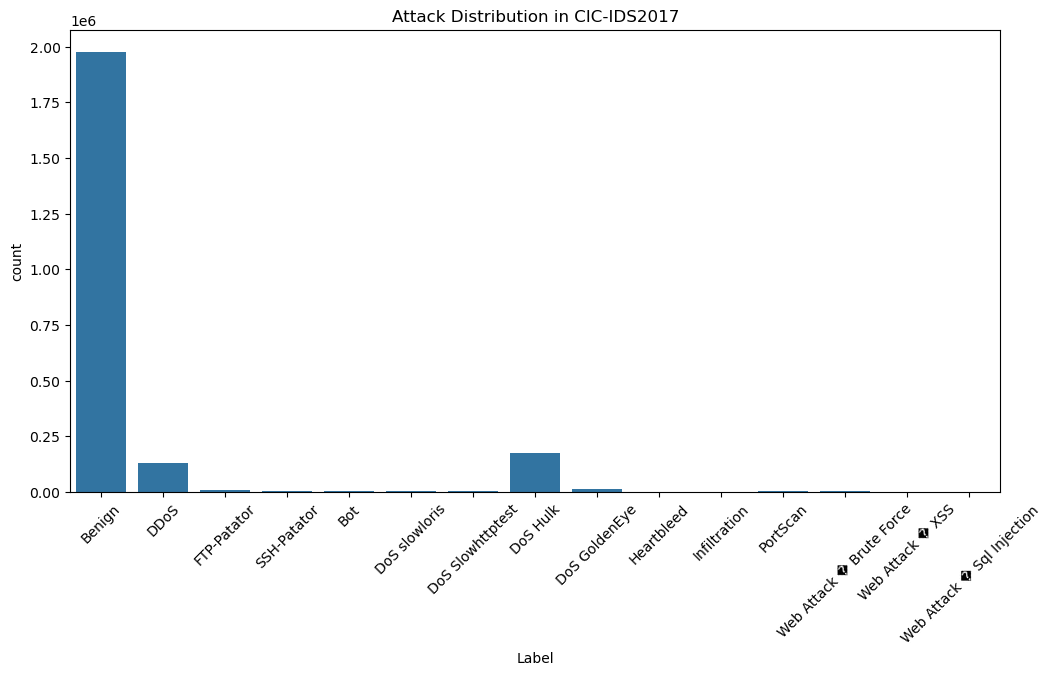

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(x="Label", data=df)
plt.xticks(rotation=45)
plt.title("Attack Distribution in CIC-IDS2017")
plt.show()


In [9]:
df["binary_label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)
df["binary_label"].value_counts(normalize=True)


binary_label
1   1.0000
Name: proportion, dtype: float64

In [10]:
df.describe().T.head(10)




,count,mean,std,min,25%,50%,75%,max
Protocol,2313810.0000,10.5067,5.4160,0.0000,6.0000,6.0000,17.0000,17.0000
Flow Duration,2313810.0000,18075748.2686,36408233.4668,-13.0000,476.0000,64783.0000,5856947.7500,119999998.0000
Total Fwd Packets,2313810.0000,11.0839,829.1879,1.0000,2.0000,2.0000,6.0000,219759.0000
Total Backward Packets,2313810.0000,12.5533,1103.1792,0.0000,1.0000,2.0000,5.0000,291922.0000
Fwd Packets Length Total,2313810.0000,666.4045,11050.0936,0.0000,37.0000,74.0000,356.0000,12900000.0000
Bwd Packets Length Total,2313810.0000,19769.7558,2503141.3456,0.0000,26.0000,183.0000,2306.0000,655453030.0000
Fwd Packet Length Max,2313810.0000,250.6291,785.5073,0.0000,20.0000,43.0000,274.0000,24820.0000
Fwd Packet Length Min,2313810.0000,21.4240,63.3419,0.0000,0.0000,6.0000,39.0000,2325.0000
Fwd Packet Length Mean,2313810.0000,68.8050,201.1606,0.0000,8.6667,39.5556,54.0000,5940.8569
Fwd Packet Length Std,2313810.0000,82.9915,300.6620,0.0000,0.0000,0.0000,84.9941,7125.5967


In [11]:
X = df.drop(["Label", "binary_label"], axis=1)
y_true = df["binary_label"]


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
y_np = y_true.values          # convert to numpy
X_normal = X_scaled[y_np == 0]
print("Benign samples:", X_normal.shape)


Benign samples: (0, 77)


In [14]:
if X_normal.shape[0] == 0:
    # Attempt to recover if binary labels are inverted (BENIGN encoded as 1)
    X_normal = X_scaled[y_np == 1]
    if X_normal.shape[0] == 0:
        raise ValueError("No BENIGN samples found. Autoencoder cannot be trained. Check binary_label encoding.")
    else:
        print(f"Recovered BENIGN samples using binary_label==1: {X_normal.shape[0]} rows.")


Recovered BENIGN samples using binary_label==1: 2313810 rows.


TRAIN AUTOENCODER ON BENIGN TRAFFIC ONLY

BUILD AUTOENCODER

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


2026-02-09 19:17:04.437023: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:
input_dim = X_normal.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 77)             │         9,933 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,685 (158.93 KB)

 Trainable params: 40,685 (158.93 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN AUTOENCODER

In [17]:
autoencoder.fit(
    X_normal,
    X_normal,
    epochs=10,
    batch_size=32,
    shuffle=True,
    callbacks=[
        EarlyStopping(
            monitor="loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 383s 5ms/step - loss: 0.2324
Epoch 2/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 343s 5ms/step - loss: 0.2095
Epoch 3/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 308s 4ms/step - loss: 0.1392
Epoch 4/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 307s 4ms/step - loss: 0.1212
Epoch 5/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 325s 4ms/step - loss: 0.1518
Epoch 6/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 269s 4ms/step - loss: 0.1082
Epoch 7/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 352s 5ms/step - loss: 0.1891
Epoch 8/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 322s 4ms/step - loss: 0.0971
Epoch 9/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 408s 5ms/step - loss: 0.1350
Epoch 10/10
72307/72307 ━━━━━━━━━━━━━━━━━━━━ 361s 5ms/step - loss: 0.0859


In [20]:
reconstructions = autoencoder.predict(X_scaled)
reconstruction_error = np.mean(np.square(X_scaled - reconstructions), axis=1)


72307/72307 ━━━━━━━━━━━━━━━━━━━━ 205s 3ms/step


In [21]:
threshold_ae = np.percentile(reconstruction_error, 95)
y_pred_ae = (reconstruction_error > threshold_ae).astype(int)


AUTOENCODER CONFUSION MATRIX

In [22]:
from sklearn.metrics import confusion_matrix, classification_report


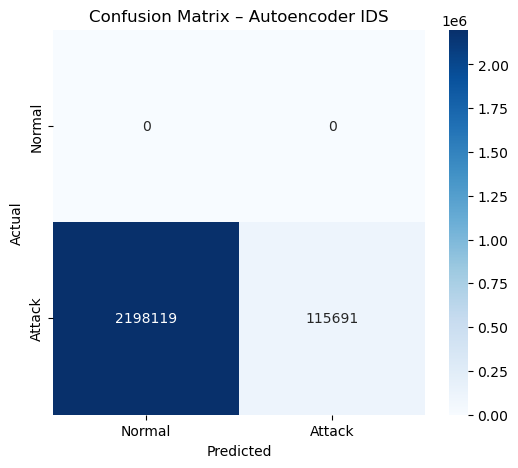

In [23]:
cm_ae = confusion_matrix(y_true, y_pred_ae)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_ae, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Autoencoder IDS")
plt.show()


In [24]:
print(classification_report(y_true, y_pred_ae, target_names=["Normal", "Attack"]))


              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
      Attack       1.00      0.05      0.10   2313810

    accuracy                           0.05   2313810
   macro avg       0.50      0.03      0.05   2313810
weighted avg       1.00      0.05      0.10   2313810



In [26]:
from sklearn.metrics import roc_curve, roc_auc_score


In [29]:
fpr_ae, tpr_ae, _ = roc_curve(y_true, reconstruction_error)
if y_true.nunique() < 2:
    # Only one class present: ROC AUC undefined
    fpr_ae = np.array([0.0, 1.0])
    tpr_ae = np.array([0.0, 1.0])
    auc_ae = np.nan
else:
    fpr_ae, tpr_ae, _ = roc_curve(y_true, reconstruction_error)
    auc_ae = roc_auc_score(y_true, reconstruction_error)


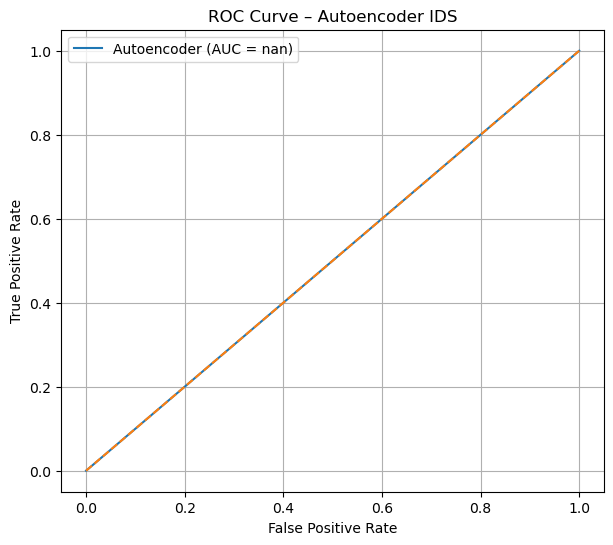

In [30]:
plt.figure(figsize=(7,6))
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC = {auc_ae:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Autoencoder IDS")
plt.legend()
plt.grid()
plt.show()


TRAIN ISOLATION FOREST

In [31]:
from sklearn.ensemble import IsolationForest


In [32]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)


IsolationForest(contamination=0.15, n_estimators=200, n_jobs=-1,
                random_state=42)

In [33]:
iso_scores = iso_forest.decision_function(X_scaled)
iso_pred = iso_forest.predict(X_scaled)
iso_pred = np.where(iso_pred == -1, 1, 0)


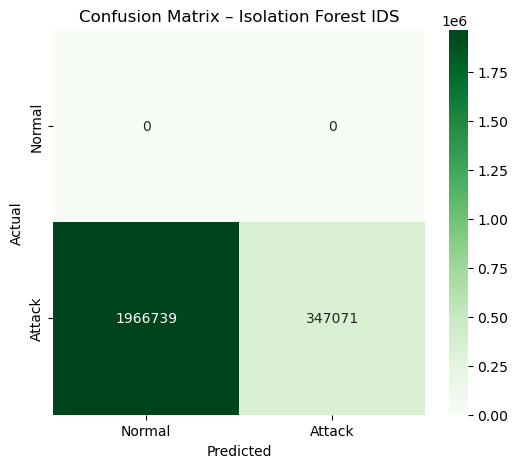

In [34]:
cm_iso = confusion_matrix(y_true, iso_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_iso, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Isolation Forest IDS")
plt.show()


In [35]:
print(classification_report(y_true, iso_pred, target_names=["Normal", "Attack"]))


              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
      Attack       1.00      0.15      0.26   2313810

    accuracy                           0.15   2313810
   macro avg       0.50      0.07      0.13   2313810
weighted avg       1.00      0.15      0.26   2313810



In [37]:
if y_true.nunique() < 2:
	# Only one class present: ROC AUC undefined
	fpr_iso = np.array([0.0, 1.0])
	tpr_iso = np.array([0.0, 1.0])
	auc_iso = np.nan
else:
	fpr_iso, tpr_iso, _ = roc_curve(y_true, -iso_scores)
	auc_iso = roc_auc_score(y_true, -iso_scores)


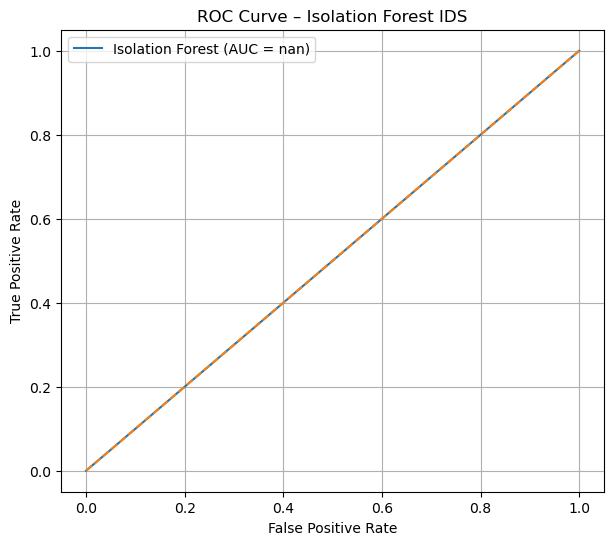

In [38]:
plt.figure(figsize=(7,6))
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC = {auc_iso:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Isolation Forest IDS")
plt.legend()
plt.grid()
plt.show()


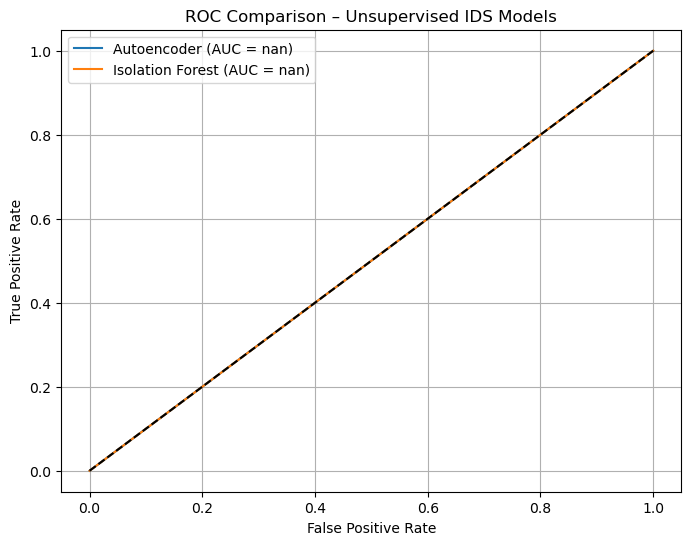

In [39]:
plt.figure(figsize=(8,6))
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC = {auc_ae:.4f})")
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC = {auc_iso:.4f})")
plt.plot([0,1], [0,1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison – Unsupervised IDS Models")
plt.legend()
plt.grid()
plt.show()


In [40]:
import joblib

autoencoder.save("autoencoder_ids_cicids.h5")
joblib.dump(iso_forest, "isolation_forest_ids.pkl")
joblib.dump(scaler, "scaler_ids.pkl")


['scaler_ids.pkl']

In [41]:
from sklearn.metrics import accuracy_score

accuracy_ae = accuracy_score(y_true, y_pred_ae)
print(f"Autoencoder IDS Accuracy: {accuracy_ae:.4f}")



Autoencoder IDS Accuracy: 0.0500


In [42]:
accuracy_iso = accuracy_score(y_true, iso_pred)
print(f"Isolation Forest IDS Accuracy: {accuracy_iso:.4f}")


Isolation Forest IDS Accuracy: 0.1500


In [43]:
accuracy_df = pd.DataFrame({
    "Model": ["Autoencoder", "Isolation Forest"],
    "Accuracy": [accuracy_ae, accuracy_iso]
})

accuracy_df


,Model,Accuracy
0,Autoencoder,0.0500
1,Isolation Forest,0.1500
